<a href="https://colab.research.google.com/github/anjicx/CNHypergraph/blob/main/Histograms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')
stays = pd.read_csv("/content/drive/MyDrive/PatientData/final_one_percent_stays.csv", sep=";")
age = pd.read_csv( "/content/drive/MyDrive/PatientData/table_age.csv",sep=";",encoding="latin1")

Mounted at /content/drive


We want to see divided by genders and age groups how long these patients occure in dataset. Patients age is the age of his first visit, and numbers of years=last visit day-first visit day(how long the patient is followed in data).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import math

In [ ]:
stays = stays.merge(age, on="ag_id", how="left")#merging age group
stays = stays.rename(columns={"age": "age_group"})
#taking men/women nonbinary has 43261 and is not therefore included
staysHistogram = stays[["patient_no", "entry_date", "exit_date", "sex_id","age_group"]].copy()
staysHistogram = staysHistogram[staysHistogram["sex_id"].isin([1, 2])].copy()#only 1 and 2 later 1=male and 2 is female
#print(staysHistogram["sex_id"].value_counts(dropna=False).sort_index())

In [ ]:
#dates to real dates
staysHistogram["entry_date"] = pd.to_datetime(staysHistogram["entry_date"])
staysHistogram["exit_date"] = pd.to_datetime(staysHistogram["exit_date"])
staysHistogram["exit_date"] = staysHistogram["exit_date"].fillna(stays["entry_date"])#if exit day is missing

#sort by patient and date
staysHistogram = staysHistogram.sort_values(["patient_no", "entry_date"])

#first and last date from patient counting:last day-first day/365.25 is no.of years per patient
patient_years = staysHistogram.groupby("patient_no").agg(
    first_date=("entry_date", "min"),
    last_date=("exit_date", "max")
).reset_index()
#years per patient
patient_years["years_per_patient"] = (
    patient_years["last_date"] - patient_years["first_date"]
).dt.days / 365.25

#from first visit for patient get age and gender
first_visit = staysHistogram.groupby("patient_no").first().reset_index()[["patient_no", "sex_id", "age_group"]]

#one patient table
patient_data = patient_years.merge(first_visit, on="patient_no", how="left")

#se label for patient_data

patient_data["sex"] = patient_data["sex_id"].map({
    1: "Male",
    2: "Female"
})

In [ ]:
patient_data = patient_data[patient_data["years_per_patient"] > 0].copy()#just those with more then 1 visit

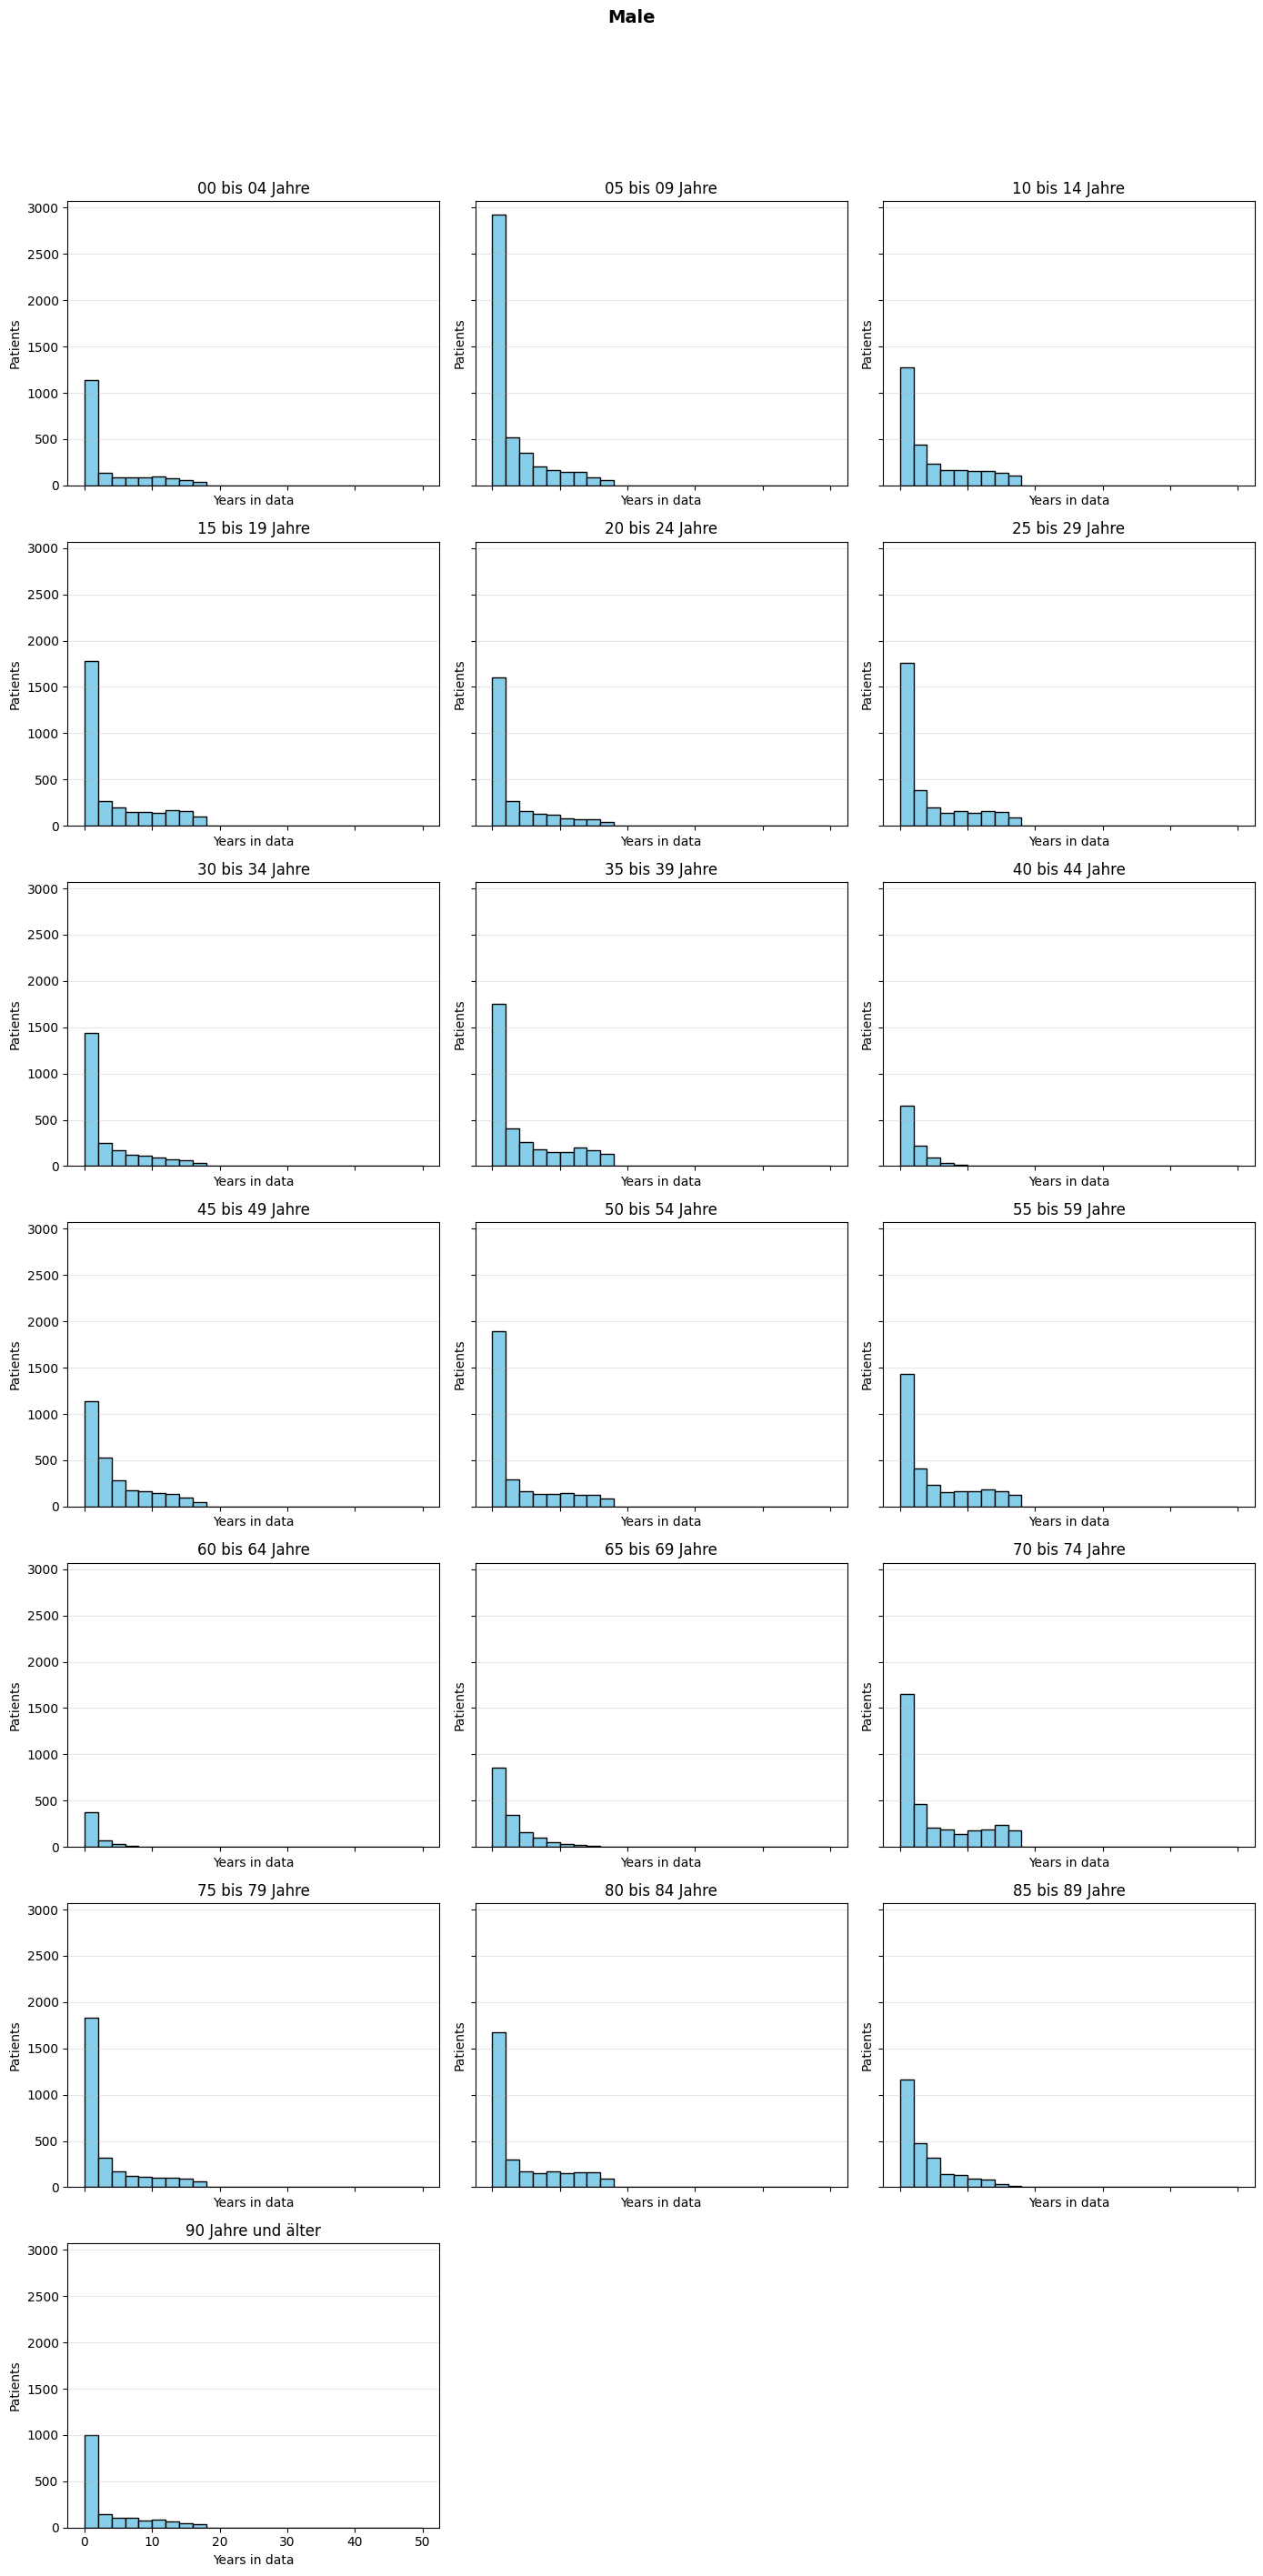

In [ ]:
import numpy as np
def plot_by_sex(sex_value, bin_width=2):
    sub = patient_data[patient_data["sex"] == sex_value].copy()
    age_groups = sorted(sub["age_group"].dropna().unique())

    max_years = np.ceil(sub["years_per_patient"].max())
    bins = np.arange(0, max_years + bin_width, bin_width)

    n = len(age_groups)
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(14, 4 * nrows),
        sharex=True,
        sharey=True
    )
    axes = np.array(axes).reshape(-1)

    for i, ag in enumerate(age_groups):
        vals = sub[sub["age_group"] == ag]["years_per_patient"].dropna()
        axes[i].hist(vals, bins=bins, color="skyblue", edgecolor="black")
        axes[i].set_title(ag)
        axes[i].set_xlabel("Years in data")
        axes[i].set_ylabel("Patients")
        axes[i].grid(axis="y", alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(f"{sex_value}",fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

plot_by_sex("Male")

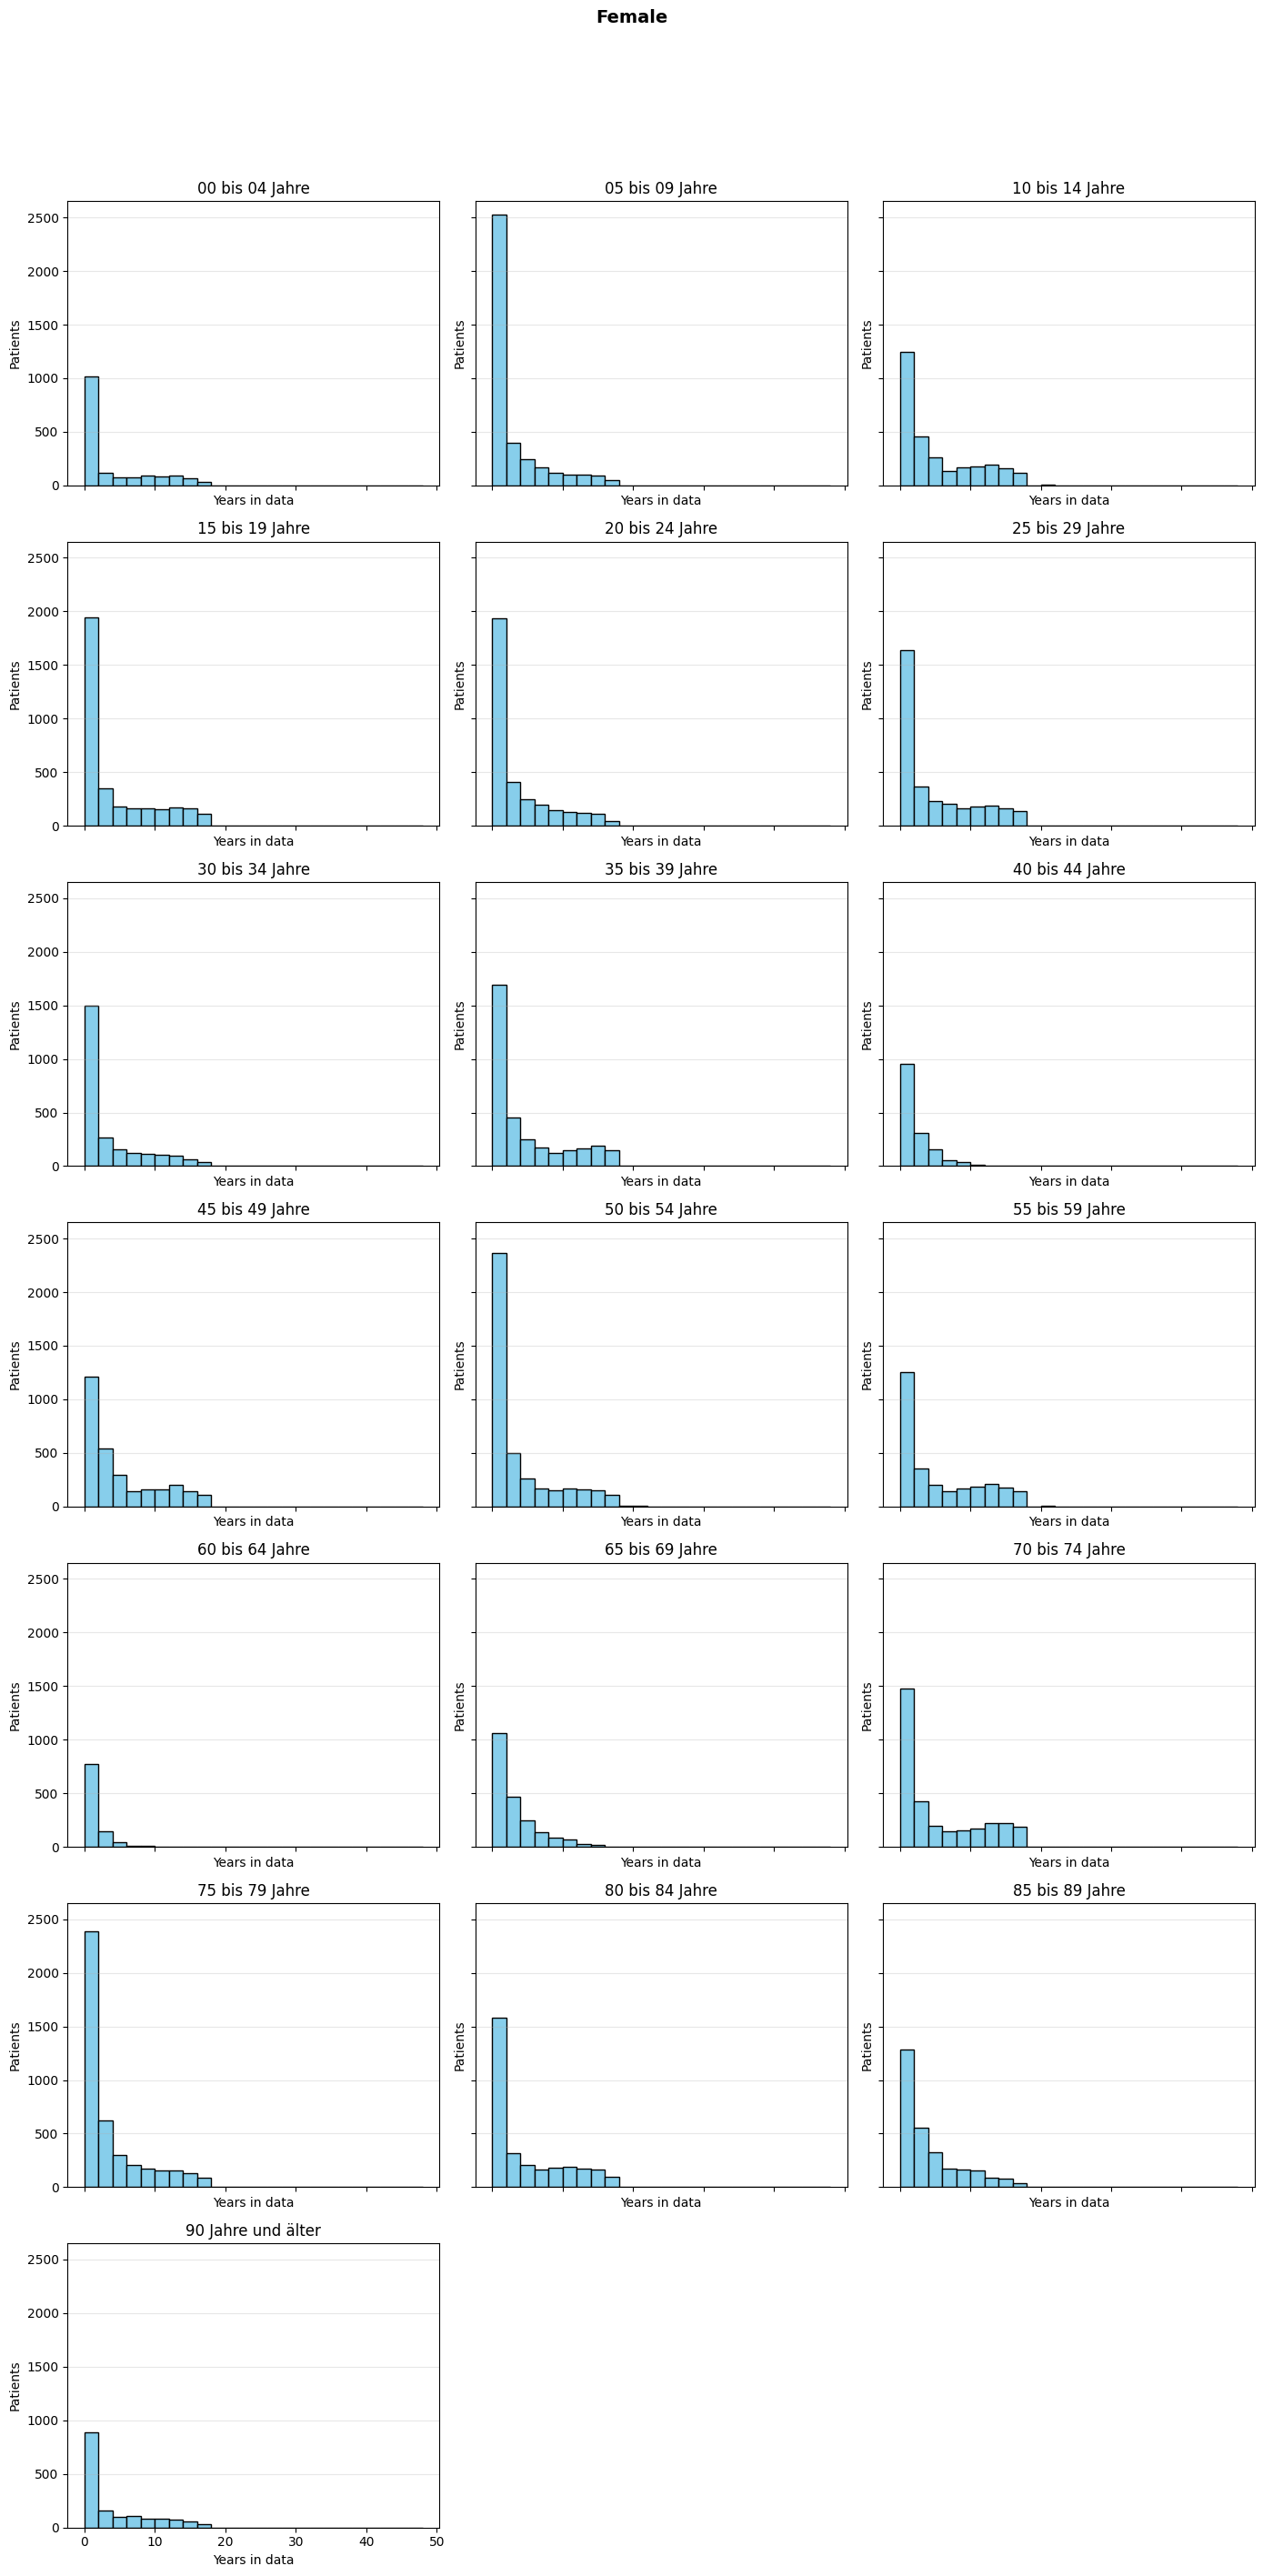

In [ ]:
plot_by_sex("Female")